In [ ]:
# Connect the drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


Found 330 images belonging to 2 classes.
Found 330 images belonging to 2 classes.
Found 330 images belonging to 2 classes.
Found 330 images belonging to 2 classes.


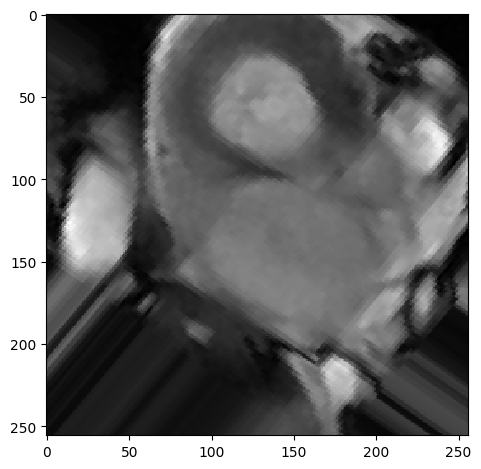

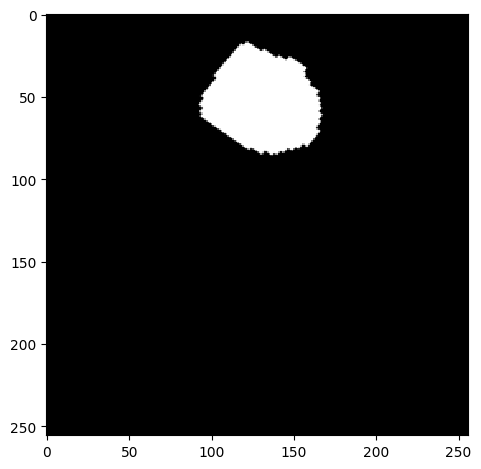

In [ ]:
#####################################################################
# Create train and validation datasets:                          #
# Image generation and augmentation                                 #
# Build image generators for training / validation images and masks #
# using the flow_from_directory Keras subroutine                    #
#####################################################################

# Import required libraries
import os
import datetime
import numpy as np
from skimage.io import imshow
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import EarlyStopping
import sys

# Paths for train and validation images
DATA_PATH = '/content/drive/MyDrive/ProjetDL2024/Dataset'
TRAIN_FRAME_PATH = DATA_PATH + '/frames'
VAL_FRAME_PATH = DATA_PATH + '/frames'
TRAIN_MASK_PATH = DATA_PATH + '/masks endo'
VAL_MASK_PATH = DATA_PATH + '/masks endo'

# Instances of ImageDataGenerator for training and validation datasets
# Geometrical data augmentation is only considered for the training dataset
# Image gray levels are normalized between 0 and 1
# outputs = train_datagen and val_datagen
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')
val_datagen = ImageDataGenerator(rescale=1./225)

BATCH_SIZE = 30  # Power of two: 4/8/16/32/64

# The images must be found in a subdir of TRAIN_FRAME_PATH for instance /Train
# Output = train_image_generator (images from TRAIN_FRAME_PATH)
train_image_generator = train_datagen.flow_from_directory(
    TRAIN_FRAME_PATH,
    target_size=(256, 256),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode=None,
    seed=123)

# The images must be found in a subdir of TRAIN_MASK_PATH for instance /Train
# Use the same seed as training images so that augmentation is the same
train_mask_generator = train_datagen.flow_from_directory(
    TRAIN_MASK_PATH,
    target_size=(256, 256),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode=None,
    seed=123)


# The images must be found in a subdir of VAL_FRAME_PATH for instance /Val
# Output = val_image_generator (images from VAL_FRAME_PATH)
val_image_generator = val_datagen.flow_from_directory(
    VAL_FRAME_PATH,
    target_size=(256, 256),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode=None,
    seed=123)

# The images must be found in a subdir of VAL_MASK_PATH for instance /Val
# Use the same seed as validation images so that aumentation is the same
val_mask_generator = val_datagen.flow_from_directory(
    VAL_MASK_PATH,
    target_size=(256, 256),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode=None,
    seed=123)

train_generator = zip(
    train_image_generator,
    train_mask_generator)

val_generator = zip(
    val_image_generator,
    val_mask_generator)


def train_generator_fn(): # Create a generator function
    for (img, mask) in train_generator:
        yield (img, mask)

def val_generator_fn(): # Create a generator function
    for (img, mask) in val_generator:
        yield (img, mask)

# Convert generators to tf.data.Dataset
train_dataset = tf.data.Dataset.from_generator(
    train_generator_fn,
    output_signature=(tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32),
                      tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32)))

val_dataset = tf.data.Dataset.from_generator(
    val_generator_fn,
    output_signature=(tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32),
                      tf.TensorSpec(shape=(BATCH_SIZE, 256, 256, 1), dtype=tf.float32)))

# Display the first generated image for the four image generators
j = 0
img = np.squeeze(train_image_generator.__next__()[j])
imshow(img)
plt.show()
img = np.squeeze(train_mask_generator.__next__()[j])
imshow(img)
plt.show()


In [ ]:
################################################################################
# Building the UNet network architecture                                       #
################################################################################

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, Conv2DTranspose

def get_UNet(img_rows, img_cols):
    inputs = Input((img_rows, img_cols, 1)) # Input layer for grayscale images

    # Downsampling path
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    # Bottleneck
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv5)

    # Upsampling path
    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv6)

    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv7)

    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv8)

    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)

    # Output layer #
    conv10 = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    # Model definition #
    model = Model(inputs=[inputs], outputs=[conv10])

    return model


In [ ]:
#################
# Training part #
#################

import sys
sys.path.append('/content/drive/MyDrive/ProjetDL2024')
import metrics_and_losses

# Load the CNN model
m = get_UNet(img_rows=256, img_cols=256)

# Optimizer
opt = tf.keras.optimizers.Adam(learning_rate=1e-4)

# Compile the model with the chosen optimizer, loss function and monitoring metrics
# Choices for loss function are Dice coefficient or binary cross-entropy
m.compile(optimizer=opt, loss=metrics_and_losses.dice_coef_loss, metrics=[metrics_and_losses.dice_coef])

# Parameters for optimization
# Model weights are saved to weights.keras when validation loss is improved
# Loss and metrics for training and validation datasets are stored in log.out at every epochs
# Optimization is stopped if there is no improvement in validation loss for at least 10 epochs
weights_path = './weights.keras'
checkpoint = ModelCheckpoint(weights_path, verbose=1, save_best_only=True)
csv_logger = CSVLogger('./log.out', append=True, separator=';')
earlystopping = EarlyStopping(verbose = 1, patience = 20)
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
callbacks_list = [checkpoint, csv_logger, earlystopping, tensorboard_callback]

# Training of model m using previously defined generators
NO_OF_EPOCHS = 70 # Between 30 and 100 for small or medium datasets
steps_per_epoch = len(train_image_generator)  # Round up
validation_steps = len(val_image_generator) # Round up

results = m.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=NO_OF_EPOCHS,
    callbacks=callbacks_list,
    validation_data=val_dataset,
    validation_steps=validation_steps)

Epoch 1/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 63s/step - dice_coef: 0.1547 - loss: 0.8453  
Epoch 1: val_loss improved from inf to 0.82411, saving model to ./weights.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 900s 83s/step - dice_coef: 0.1547 - loss: 0.8453 - val_dice_coef: 0.1759 - val_loss: 0.8241
Epoch 2/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 62s/step - dice_coef: 0.1616 - loss: 0.8384  
Epoch 2: val_loss improved from 0.82411 to 0.82290, saving model to ./weights.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 875s 81s/step - dice_coef: 0.1616 - loss: 0.8384 - val_dice_coef: 0.1771 - val_loss: 0.8229
Epoch 3/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 62s/step - dice_coef: 0.1579 - loss: 0.8421  
Epoch 3: val_loss improved from 0.82290 to 0.81571, saving model to ./weights.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 887s 83s/step - dice_coef: 0.1581 - loss: 0.8419 - val_dice_coef: 0.1843 - val_loss: 0.8157
Epoch 4/70
 6/11 ━━━━━━━━━━━━━━━━━━━━ 5:12 62s/step - dice_coef: 0.1684 - loss: 0.8316

In [ ]:
# Save final model weights
m.save_weights('./weights.weights.h5')
m.save('./weights.model.h5')